In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm.notebook import tqdm  # Dùng tqdm.notebook để hiển thị đẹp hơn trên Kaggle/Jupyter
from PIL import Image

# Cấu hình hiển thị biểu đồ
sns.set_style("whitegrid")

--> Đang đọc dữ liệu từ: /kaggle/input/concrete-wall-damage-classification/Data

Đang phân tích chi tiết 3470 ảnh. Vui lòng chờ...


  0%|          | 0/3470 [00:00<?, ?it/s]


                PHẦN EDA                

[1] TỔNG QUAN SỐ LƯỢNG:
   - Tổng file quét được: 3470
   - File lỗi (Corrupted): 0 file
   - File đọc thành công: 3470 file
   - Phân bố nhãn (trên file thành công):
     + Damaged: 2407 ảnh (69.4%)
     + UnDamaged: 1063 ảnh (30.6%)

[2] KÍCH THƯỚC ẢNH (Dimensions):
   -> Tất cả ảnh đồng nhất kích thước (224, 224)

[3] MÀU SẮC & ÁNH SÁNG:
   - RGB Trung bình: R=156.6, G=143.8, B=129.4
     -> Nhận xét: Ảnh thiên về tông màu Red.
   - Độ sáng trung bình: 159.6/255
     -> Nhận xét: Độ sáng ổn định.

--------------------------------------------------
ĐANG VẼ CÁC BIỂU ĐỒ THỐNG KÊ...


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_conte

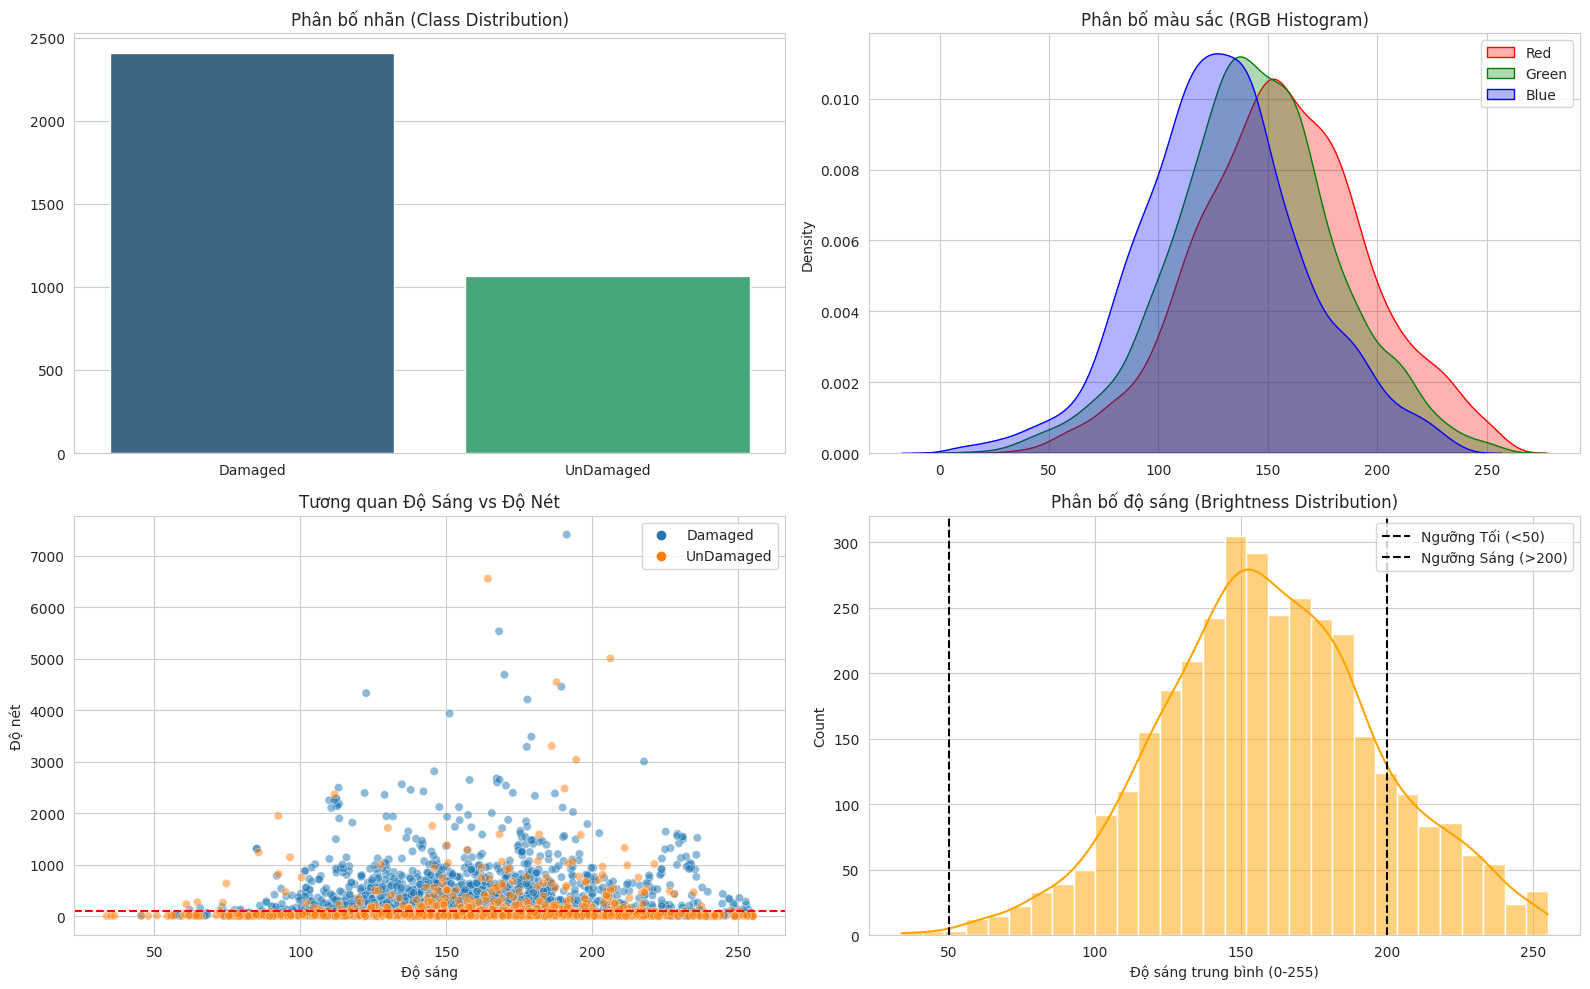


--------------------------------------------------
Hiển thị ảnh mẫu (Visualize samples)...


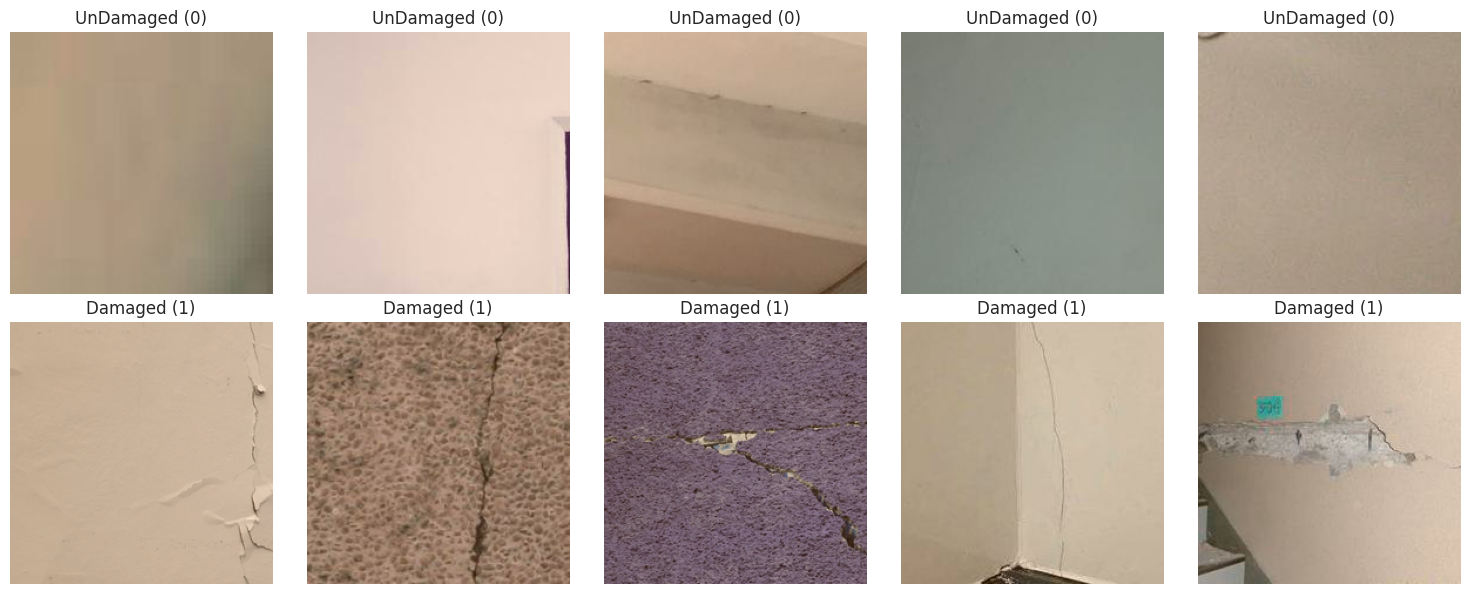

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
from collections import Counter

INPUT_ROOT = '/kaggle/input'
TARGET_FOLDER = 'Data_task2' 

label_map = {
    'UnDamaged': 0, 
    'Damaged': 1    
}

# Hàm tìm đường dẫn dataset tự động
def find_dataset_path(root, target):
    for dirpath, dirnames, filenames in os.walk(root):
        if target in dirnames:
            return Path(os.path.join(dirpath, target))
    return Path('/kaggle/input/concrete-wall-damage-classification/Data')

dataset_path = find_dataset_path(INPUT_ROOT, TARGET_FOLDER)
print(f"--> Đang đọc dữ liệu từ: {dataset_path}")

# --- KHỞI TẠO BIẾN LƯU TRỮ ---
stats = {
    'total_scanned': 0,
    'filepaths': [],      # Lưu đường dẫn để tạo DataFrame
    'labels': [],         # Lưu nhãn chữ để tạo DataFrame
    'widths': [],
    'heights': [],
    'red_mean': [],
    'green_mean': [],
    'blue_mean': [],
    'brightness': [], 
    'blur_scores': [],
    'corrupted_files': [],
    'blurry_candidates': []
}

BLUR_THRESHOLD = 100 

# --- VÒNG LẶP QUÉT DỮ LIỆU ---
filepaths = list(dataset_path.glob('*/*')) 
stats['total_scanned'] = len(filepaths)

print(f"\nĐang phân tích chi tiết {len(filepaths)} ảnh. Vui lòng chờ...")

for filepath in tqdm(filepaths):
    str_path = str(filepath)
    label = filepath.parent.name 
    
    # 1. Kiểm tra File Hỏng
    try:
        with Image.open(str_path) as img:
            img.verify() 
    except (IOError, SyntaxError):
        stats['corrupted_files'].append(str_path)
        continue 

    # 2. Đọc ảnh và tính toán
    try:
        img = cv2.imread(str_path)
        if img is None:
            stats['corrupted_files'].append(str_path)
            continue

        # Lưu thông tin cơ bản để tạo DataFrame sau này
        stats['filepaths'].append(str_path)
        stats['labels'].append(label)

        # Lấy kích thước
        h, w, c = img.shape
        stats['widths'].append(w)
        stats['heights'].append(h)

        # Màu sắc (RGB)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        stats['red_mean'].append(np.mean(img_rgb[:, :, 0]))
        stats['green_mean'].append(np.mean(img_rgb[:, :, 1]))
        stats['blue_mean'].append(np.mean(img_rgb[:, :, 2]))

        # --- ĐỘ SÁNG (BRIGHTNESS) ---
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        bright_val = np.mean(hsv[:, :, 2])
        stats['brightness'].append(bright_val)

        # Độ mờ
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blur_val = cv2.Laplacian(gray, cv2.CV_64F).var()
        stats['blur_scores'].append(blur_val)
        
        if blur_val < BLUR_THRESHOLD:
            stats['blurry_candidates'].append(str_path)

    except Exception as e:
        print(f"Lỗi lạ tại file {filepath.name}: {e}")

# --- TẠO DATAFRAME (Để dùng cho Visualize Samples) ---
df = pd.DataFrame({
    'filepath': stats['filepaths'],
    'label_str': stats['labels']
})
# Map nhãn số vào cột 'label' (UnDamaged=0, Damaged=1)
df['label'] = df['label_str'].map(label_map)


# --- HIỂN THỊ BÁO CÁO (TEXT REPORT) ---
print("\n" + "="*40)
print(f"{'PHẦN EDA':^40}")
print("="*40)

# 1. Số lượng
num_success = len(stats['widths'])
label_counts = Counter(stats['labels'])

print(f"\n[1] TỔNG QUAN SỐ LƯỢNG:")
print(f"   - Tổng file quét được: {stats['total_scanned']}")
print(f"   - File lỗi (Corrupted): {len(stats['corrupted_files'])} file")
print(f"   - File đọc thành công: {num_success} file")
print(f"   - Phân bố nhãn (trên file thành công):")
for lab, count in label_counts.items():
    percent = (count / num_success) * 100 if num_success > 0 else 0
    print(f"     + {lab}: {count} ảnh ({percent:.1f}%)")

# 2. Kích thước
unique_size = set(zip(stats['widths'], stats['heights']))
print(f"\n[2] KÍCH THƯỚC ẢNH (Dimensions):")
if len(unique_size) == 1:
    print(f"   -> Tất cả ảnh đồng nhất kích thước {list(unique_size)[0]}")
else:
    print(f"   -> Có {len(unique_size)} kích thước khác nhau.")
    print(f"      Ví dụ: {list(unique_size)[:3]}...")

# 3. Màu sắc & Ánh sáng
avg_r = np.mean(stats['red_mean'])
avg_g = np.mean(stats['green_mean'])
avg_b = np.mean(stats['blue_mean'])
avg_bright = np.mean(stats['brightness'])

dom_color_idx = np.argmax([avg_r, avg_g, avg_b])
dom_color = ['Red', 'Green', 'Blue'][dom_color_idx]

print(f"\n[3] MÀU SẮC & ÁNH SÁNG:")
print(f"   - RGB Trung bình: R={avg_r:.1f}, G={avg_g:.1f}, B={avg_b:.1f}")
if max(avg_r, avg_g, avg_b) - min(avg_r, avg_g, avg_b) < 10:
    print("     -> Nhận xét: Màu sắc cân bằng (hoặc ảnh xám/trắng đen).")
else:
    print(f"     -> Nhận xét: Ảnh thiên về tông màu {dom_color}.")

print(f"   - Độ sáng trung bình: {avg_bright:.1f}/255")
if avg_bright < 50: print("     -> Nhận xét:  Dataset rất tối.")
elif avg_bright > 200: print("     -> Nhận xét:  Dataset có độ sáng cao.")
else: print("     -> Nhận xét: Độ sáng ổn định.")


# --- PHẦN 1: VẼ BIỂU ĐỒ PHÂN TÍCH (THỐNG KÊ) ---
print("\n" + "-"*50)
print("ĐANG VẼ CÁC BIỂU ĐỒ THỐNG KÊ...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Biểu đồ 1: Số lượng Class
sns.barplot(x=list(label_counts.keys()), y=list(label_counts.values()), ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title("Phân bố nhãn (Class Distribution)")

# Biểu đồ 2: Histogram Màu sắc RGB
sns.kdeplot(stats['red_mean'], color='red', fill=True, alpha=0.3, ax=axes[0, 1], label='Red')
sns.kdeplot(stats['green_mean'], color='green', fill=True, alpha=0.3, ax=axes[0, 1], label='Green')
sns.kdeplot(stats['blue_mean'], color='blue', fill=True, alpha=0.3, ax=axes[0, 1], label='Blue')
axes[0, 1].set_title("Phân bố màu sắc (RGB Histogram)")
axes[0, 1].legend()

# Biểu đồ 3: Tương quan Độ sáng vs Độ nét
sns.scatterplot(x=stats['brightness'], y=stats['blur_scores'], alpha=0.5, hue=stats['labels'], ax=axes[1, 0])
axes[1, 0].set_title("Tương quan Độ Sáng vs Độ Nét")
axes[1, 0].set_xlabel("Độ sáng")
axes[1, 0].set_ylabel("Độ nét")
axes[1, 0].axhline(y=BLUR_THRESHOLD, color='red', linestyle='--')

# Biểu đồ 4: Phân bố Độ sáng
sns.histplot(stats['brightness'], color='orange', kde=True, bins=30, ax=axes[1, 1])
axes[1, 1].axvline(x=50, color='black', linestyle='--', label='Ngưỡng Tối (<50)')
axes[1, 1].axvline(x=200, color='black', linestyle='--', label='Ngưỡng Sáng (>200)')
axes[1, 1].set_title('Phân bố độ sáng (Brightness Distribution)')
axes[1, 1].set_xlabel('Độ sáng trung bình (0-255)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ---VISUALIZE SAMPLES  ---
print("\n" + "-"*50)
print("Hiển thị ảnh mẫu (Visualize samples)...")

def visualize_samples(df, num_samples=5):
    # Kiểm tra xem có đủ ảnh không, tránh lỗi nếu dataset quá nhỏ
    try:
        plt.figure(figsize=(15, 6))
        for i, category in enumerate(label_map.keys()): # Duyệt qua UnDamaged và Damaged
            # Lọc dataframe theo nhãn
            subset = df[df['label_str'] == category]
            
            # Nếu số lượng ảnh ít hơn num_samples, lấy hết số ảnh đang có
            actual_samples = min(len(subset), num_samples)
            if actual_samples == 0: continue

            sample_df = subset.sample(actual_samples)
            
            for j, (idx, row) in enumerate(sample_df.iterrows()):
                plt.subplot(2, num_samples, i * num_samples + j + 1)
                img = cv2.imread(row['filepath'])
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    plt.imshow(img)
                    plt.title(f"{category} ({row['label']})")
                    plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Lỗi khi hiển thị ảnh mẫu: {e}")

# Gọi hàm hiển thị
visualize_samples(df)

In [3]:
def save_eda_plots_separate(stats, label_counts, BLUR_THRESHOLD, save_dir="eda_outputs"):
    import os
    import matplotlib.pyplot as plt
    import seaborn as sns

    os.makedirs(save_dir, exist_ok=True)

    # ===== 1. Class Distribution =====
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=list(label_counts.keys()),
        y=list(label_counts.values()),
        palette='viridis'
    )
    plt.title("Phân bố nhãn (Class Distribution)", fontsize=14)
    plt.ylabel("Số lượng ảnh")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/class_distribution.png", dpi=300)
    plt.close()

    # ===== 2. RGB Distribution =====
    plt.figure(figsize=(10, 5))
    sns.kdeplot(stats['red_mean'], color='red', fill=True, alpha=0.3, label='Red')
    sns.kdeplot(stats['green_mean'], color='green', fill=True, alpha=0.3, label='Green')
    sns.kdeplot(stats['blue_mean'], color='blue', fill=True, alpha=0.3, label='Blue')
    plt.title("Phân bố màu sắc (RGB Histogram)", fontsize=14)
    plt.xlabel("Giá trị trung bình")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{save_dir}/rgb_distribution.png", dpi=300)
    plt.close()

    # ===== 3. Brightness vs Blur =====
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x=stats['brightness'],
        y=stats['blur_scores'],
        hue=stats['labels'],
        alpha=0.5
    )
    plt.axhline(y=BLUR_THRESHOLD, color='red', linestyle='--', label='Blur threshold')
    plt.title("Tương quan Độ Sáng vs Độ Nét", fontsize=14)
    plt.xlabel("Độ sáng")
    plt.ylabel("Độ nét")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{save_dir}/brightness_vs_blur.png", dpi=300)
    plt.close()

    # ===== 4. Brightness Distribution =====
    plt.figure(figsize=(10, 5))
    sns.histplot(stats['brightness'], kde=True, bins=30, color='orange')
    plt.axvline(x=50, color='black', linestyle='--', label='Ngưỡng Tối (<50)')
    plt.axvline(x=200, color='black', linestyle='--', label='Ngưỡng Sáng (>200)')
    plt.title("Phân bố độ sáng (Brightness Distribution)", fontsize=14)
    plt.xlabel("Độ sáng trung bình (0-255)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{save_dir}/brightness_distribution.png", dpi=300)
    plt.close()

    print(f"✅ Đã lưu 4 biểu đồ RỘNG tại: {save_dir}/")

save_eda_plots_separate(stats, label_counts, BLUR_THRESHOLD)


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_conte

✅ Đã lưu 4 biểu đồ RỘNG tại: eda_outputs/


In [4]:
corrupted_files = []

print("Đang kiểm tra file lỗi...")

# Duyệt qua TOÀN BỘ dữ liệu (không dùng sample)
for filepath in tqdm(df['filepath']):
    try:
        with Image.open(filepath) as img:
            img.verify() # Kiểm tra cấu trúc file
    except (IOError, SyntaxError) as e:
        print(f"Phát hiện file lỗi: {filepath}")
        corrupted_files.append(filepath)

print("-" * 30)
if len(corrupted_files) == 0:
    print("Không có file nào bị lỗi định dạng.")
else:
    print(f"Tìm thấy {len(corrupted_files)} file bị lỗi.")

Đang kiểm tra file lỗi...


  0%|          | 0/3470 [00:00<?, ?it/s]

------------------------------
Không có file nào bị lỗi định dạng.


In [5]:
from sklearn.model_selection import train_test_split
import albumentations as A
import cv2
import uuid
import shutil
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# --- CẤU HÌNH ---
SEED = 42
TEST_SIZE = 0.15   # 15% dữ liệu cho Test 
VAL_SIZE = 0.15    # 15% dữ liệu cho Validation 
# -> 70% dữ liệu còn lại sẽ dành cho Train

print("\n" + "="*40)
print(f"{'PHẦN 2: CHIA TẬP DỮ LIỆU (SPLIT DATA)':^40}")
print("="*40)

# 1. Tách tập Test ra trước (Stratified để giữ tỷ lệ nhãn)
train_val_df, test_df = train_test_split(
    df, 
    test_size=TEST_SIZE, 
    stratify=df['label'], 
    random_state=SEED
)

# 2. Tách tập Train và Validation từ phần còn lại
# Tính toán tỷ lệ tương đối để Val chiếm 15% tổng dataset gốc
relative_val_size = VAL_SIZE / (1 - TEST_SIZE) 

train_df, val_df = train_test_split(
    train_val_df, 
    test_size=relative_val_size, 
    stratify=train_val_df['label'], 
    random_state=SEED
)

# Reset index để tránh lỗi khi truy cập sau này
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Tổng số file: {len(df)}")
print(f"-> Train set: {len(train_df)} ảnh (Đã giữ nguyên toàn bộ, không lọc)")
print(f"-> Val set:   {len(val_df)} ảnh")
print(f"-> Test set:  {len(test_df)} ảnh")

# Kiểm tra phân bố nhãn trong tập Train gốc
print("\nPhân bố nhãn trong tập Train (Gốc):")
print(train_df['label_str'].value_counts())

# --- SINH DỮ LIỆU TỔNG HỢP (SYNTHETIC DATA) ---
# Mục đích: Chỉ cân bằng số lượng lớp UnDamaged cho bằng Damaged.
# Phần này chỉ tiền xử lí và tăng cường trong tập TRAIN.

SYNTHETIC_DIR = 'synthetic_data'
if not os.path.exists(SYNTHETIC_DIR):
    os.makedirs(SYNTHETIC_DIR)

# Pipeline Augmentation để sinh ảnh mới
# Tập trung vào xoay, lật, chỉnh độ sáng nhẹ
aug_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=30, border_mode=cv2.BORDER_REFLECT, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
])

def generate_synthetic_data(df_input):
    # Copy để không ảnh hưởng df gốc ngay lập tức
    df_aug = df_input.copy()
    
    # Đếm số lượng
    counts = df_aug['label'].value_counts()
    class_0_count = counts.get(0, 0) # UnDamaged
    class_1_count = counts.get(1, 0) # Damaged
    
    # Xác định lớp thiếu (thường là UnDamaged - 0)
    target_count = max(class_0_count, class_1_count)
    needed = target_count - class_0_count
    
    if needed <= 0:
        print("Dữ liệu lớp UnDamaged đã đủ hoặc nhiều hơn. Không sinh thêm.")
        return df_aug

    print(f"\n--> Đang sinh thêm {needed} ảnh nhân tạo cho lớp UnDamaged...")
    
    # Lấy danh sách ảnh UnDamaged gốc
    minority_df = df_aug[df_aug['label'] == 0]
    new_rows = []
    
    # Vòng lặp sinh dữ liệu
    while len(new_rows) < needed:
        # Duyệt qua từng ảnh gốc
        for idx, row in minority_df.iterrows():
            if len(new_rows) >= needed:
                break
                
            img_path = row['filepath']
            try:
                # Đọc ảnh
                img = cv2.imread(img_path)
                if img is None: continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                # Augment tạo ảnh mới
                augmented = aug_pipeline(image=img)['image']
                
                # Lưu ảnh
                fname = f"syn_{uuid.uuid4().hex[:10]}.jpg"
                save_path = os.path.join(SYNTHETIC_DIR, fname)
                
                # Convert về BGR để lưu bằng OpenCV
                img_to_save = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
                cv2.imwrite(save_path, img_to_save)
                
                # Thêm thông tin vào list
                new_data = row.to_dict()
                new_data['filepath'] = save_path
                new_data['is_synthetic'] = True # Đánh dấu là ảnh sinh ra
                new_rows.append(new_data)
                
            except Exception as e:
                pass

    # Gộp dữ liệu mới vào dữ liệu Train
    synthetic_df = pd.DataFrame(new_rows)
    df_final = pd.concat([df_aug, synthetic_df], ignore_index=True)
    
    return df_final

# Thực hiện sinh dữ liệu (Chỉ trên tập Train)
print("="*40)
print("BẮT ĐẦU SINH DỮ LIỆU...")
train_df_balanced = generate_synthetic_data(train_df)

print("\nPhân bố nhãn tập Train sau khi cân bằng:")
print(train_df_balanced['label_str'].value_counts())
print(f"Tổng số ảnh tập Train sau khi xử lý: {len(train_df_balanced)}")

# --- PHẦN 4: TẠO DATASET & DATALOADER ---
# Chuẩn bị để đưa vào model

# ImageNet statistics (Chuẩn cho Transfer Learning)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

class ConcreteDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['filepath']
        label = row['label']
        
        # Đọc ảnh
        image = cv2.imread(img_path)
        # Phòng trường hợp lỗi file ảnh (dù đã check ở EDA)
        if image is None:
            # Trả về ảnh đen nếu lỗi (hoặc xử lý khác tùy bạn)
            image = np.zeros((224, 224, 3), dtype=np.uint8)
            
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Transform
        if self.transform:
            image = self.transform(image=image)['image']
            
        # To Tensor & Normalize
        image = transforms.ToTensor()(image)
        normalizer = transforms.Normalize(mean=MEAN, std=STD)
        image = normalizer(image)
        
        return image, torch.tensor(label, dtype=torch.long)

# Định nghĩa Transform
# Train: Vẫn có Augmentation nhẹ (như crop, cutout) để model học tốt hơn
train_transform = A.Compose([
    A.Resize(224, 224),
    A.CoarseDropout(max_holes=8, max_height=20, max_width=20, p=0.2), # Giả lập mất mát chi tiết
])

# Val/Test: Chỉ Resize chuẩn
val_test_transform = A.Compose([
    A.Resize(224, 224),
])

# Tạo Dataset
train_ds = ConcreteDataset(train_df_balanced, transform=train_transform)
val_ds   = ConcreteDataset(val_df, transform=val_test_transform)
test_ds  = ConcreteDataset(test_df, transform=val_test_transform)

# Tạo DataLoader
BATCH_SIZE = 32
NUM_WORKERS = 2 

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("\n--> Đã khởi tạo xong DataLoader!")
print(f"Số batch train: {len(train_loader)}")
print(f"Số batch val:   {len(val_loader)}")
print(f"Số batch test:  {len(test_loader)}")


 PHẦN 2: CHIA TẬP DỮ LIỆU (SPLIT DATA)  
Tổng số file: 3470
-> Train set: 2428 ảnh (Đã giữ nguyên toàn bộ, không lọc)
-> Val set:   521 ảnh
-> Test set:  521 ảnh

Phân bố nhãn trong tập Train (Gốc):
label_str
Damaged      1685
UnDamaged     743
Name: count, dtype: int64
BẮT ĐẦU SINH DỮ LIỆU...

--> Đang sinh thêm 942 ảnh nhân tạo cho lớp UnDamaged...


/tmp/ipykernel_47/874102925.py:69: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),



Phân bố nhãn tập Train sau khi cân bằng:
label_str
Damaged      1685
UnDamaged    1685
Name: count, dtype: int64
Tổng số ảnh tập Train sau khi xử lý: 3370

--> Đã khởi tạo xong DataLoader!
Số batch train: 106
Số batch val:   17
Số batch test:  17


/tmp/ipykernel_47/874102925.py:188: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=20, max_width=20, p=0.2), # Giả lập mất mát chi tiết



         BẢNG TỔNG HỢP DỮ LIỆU SAU XỬ LÝ          
label_str   Damaged  UnDamaged  Total Images
Train          1685       1685          3370
Validation      361        160           521
Test            361        160           521


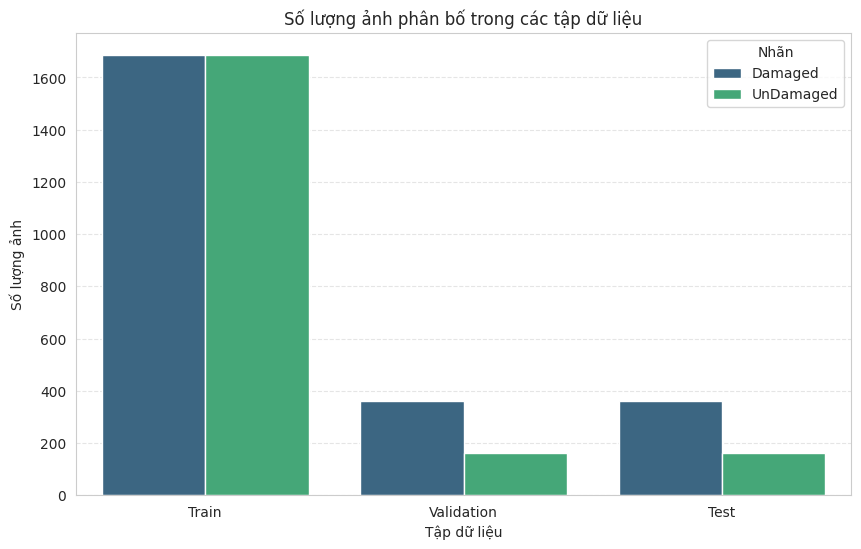

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- PHẦN 5: BÁO CÁO THỐNG KÊ CHI TIẾT (FINAL REPORT) ---
print("\n" + "="*50)
print(f"{'BẢNG TỔNG HỢP DỮ LIỆU SAU XỬ LÝ':^50}")
print("="*50)

# 1. Tổng hợp dữ liệu
# Lấy value_counts từ từng tập dataframe
train_counts = train_df_balanced['label_str'].value_counts()
val_counts = val_df['label_str'].value_counts()
test_counts = test_df['label_str'].value_counts()

# Tạo DataFrame tổng hợp
summary_df = pd.DataFrame({
    'Train': train_counts,
    'Validation': val_counts,
    'Test': test_counts
}).T  # Chuyển vị (Transpose) để hàng là các tập dữ liệu

# Thay thế NaN bằng 0 (phòng trường hợp thiếu class) và chuyển về số nguyên
summary_df = summary_df.fillna(0).astype(int)

# Tính cột Tổng cộng
summary_df['Total Images'] = summary_df.sum(axis=1)

# Hiển thị bảng số liệu
print(summary_df)

# 2. Vẽ biểu đồ so sánh trực quan (Tùy chọn)
plt.figure(figsize=(10, 6))
# Chuyển dữ liệu về dạng long-form để vẽ bằng seaborn
summary_long = summary_df.reset_index().melt(id_vars='index', value_vars=['Damaged', 'UnDamaged'], 
                                             var_name='Label', value_name='Count')

sns.barplot(data=summary_long, x='index', y='Count', hue='Label', palette='viridis')
plt.title('Số lượng ảnh phân bố trong các tập dữ liệu')
plt.xlabel('Tập dữ liệu')
plt.ylabel('Số lượng ảnh')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Nhãn')
plt.show()


 SO SÁNH ẢNH GỐC và AUGMENTATION: DAMAGED 


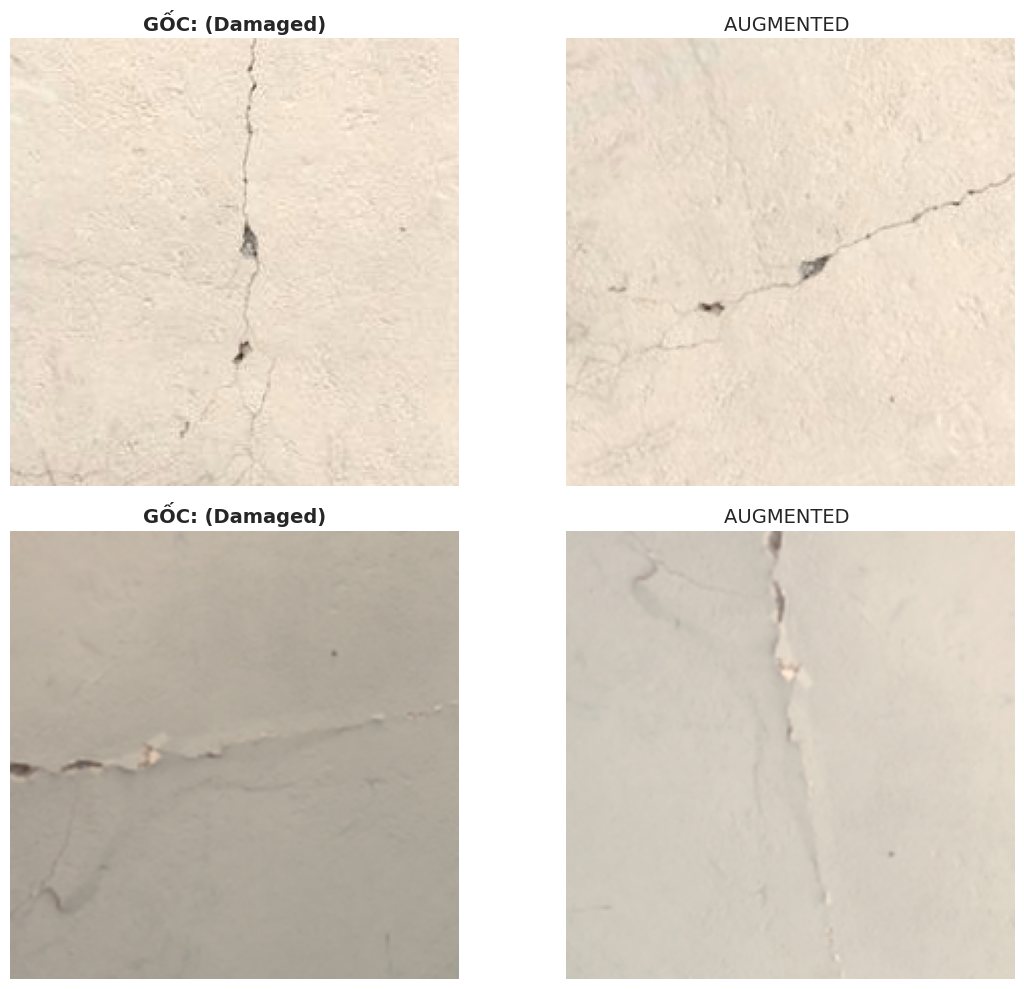


 SO SÁNH ẢNH GỐC và AUGMENTATION: UNDAMAGED 


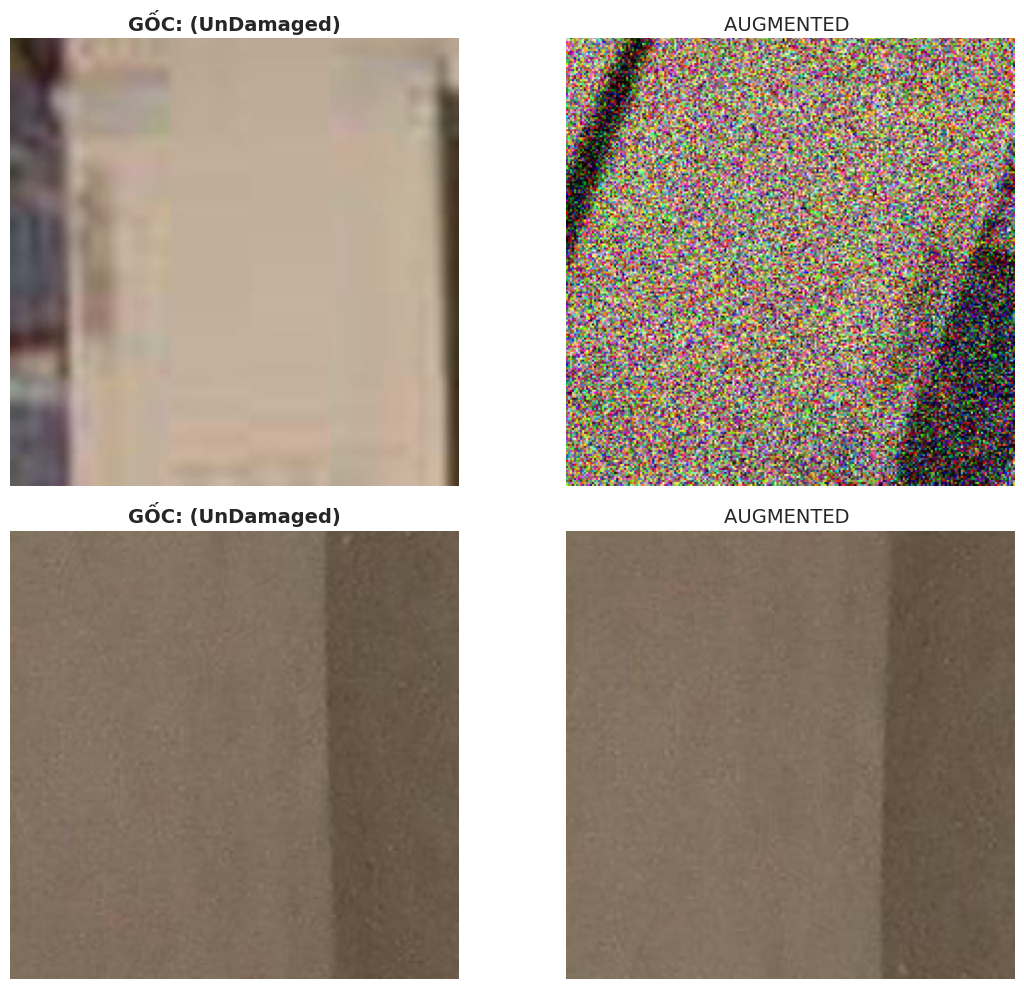

In [7]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# --- HÀM VISUALIZE AUGMENTATION ---
def visualize_augmentation(df_input, pipeline, label_target, num_samples=2):

    print(f"\n{'='*40}")
    print(f" SO SÁNH ẢNH GỐC và AUGMENTATION: {label_target.upper()} ")
    print(f"{'='*40}")

    #
    subset = df_input[df_input['label_str'] == label_target]
    if len(subset) < num_samples:
        samples = subset
    else:
        
        samples = subset.sample(num_samples, random_state=99)

    plt.figure(figsize=(12, 5 * len(samples)))

    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = row['filepath']
        
        image = cv2.imread(img_path)
        if image is None: continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        augmented_image = pipeline(image=image)['image']

        plt.subplot(len(samples), 2, 2*i + 1)
        plt.imshow(image)
        plt.title(f"GỐC: ({label_target})", fontsize=14, fontweight='bold')
        plt.axis('off')

        plt.subplot(len(samples), 2, 2*i + 2)
        plt.imshow(augmented_image)
        plt.title("AUGMENTED ", fontsize=14)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


visualize_augmentation(train_df, aug_pipeline, label_target='Damaged', num_samples=2)
visualize_augmentation(train_df, aug_pipeline, label_target='UnDamaged', num_samples=2)

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import copy
import time
import os
import shutil

# --- CẤU HÌNH ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 10
LEARNING_RATE = 1e-4
CLASS_NAMES = ['UnDamaged', 'Damaged']
OUTPUT_DIR = 'training_results'

# Tạo thư mục gốc (Xóa cũ tạo mới nếu cần)
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Running on device: {device}")
print(f"Kết quả sẽ được lưu tại: {OUTPUT_DIR}/")

# --- 1. HÀM KHỞI TẠO MODEL ---
def get_model(model_name):
    print(f"\nDang khoi tao: {model_name}...")
    if model_name == 'ResNet18':
        model = models.resnet18(weights='DEFAULT')
        model.fc = nn.Linear(model.fc.in_features, 2)
    elif model_name == 'MobileNetV2':
        model = models.mobilenet_v2(weights='DEFAULT')
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
    elif model_name == 'EfficientNet-B0':
        model = models.efficientnet_b0(weights='DEFAULT')
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
    elif model_name == 'VGG16_BN':
        model = models.vgg16_bn(weights='DEFAULT')
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, 2)
    elif model_name == 'DenseNet121':
        model = models.densenet121(weights='DEFAULT')
        model.classifier = nn.Linear(model.classifier.in_features, 2)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")
    return model.to(device)

# --- 2. HÀM TRAIN ---
def train_engine(model, train_loader, val_loader, model_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    start_time = time.time()
    for epoch in range(EPOCHS):
        # Train Phase
        model.train()
        r_loss, r_corrects = 0.0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            r_loss += loss.item() * inputs.size(0)
            r_corrects += torch.sum(preds == labels.data)

        e_loss = r_loss / len(train_loader.dataset)
        e_acc = r_corrects.double() / len(train_loader.dataset)

        # Val Phase
        model.eval()
        v_loss, v_corrects = 0.0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                v_loss += loss.item() * inputs.size(0)
                v_corrects += torch.sum(preds == labels.data)

        e_v_loss = v_loss / len(val_loader.dataset)
        e_v_acc = v_corrects.double() / len(val_loader.dataset)

        history['train_loss'].append(e_loss)
        history['train_acc'].append(e_acc.item())
        history['val_loss'].append(e_v_loss)
        history['val_acc'].append(e_v_acc.item())

        if e_v_acc > best_acc:
            best_acc = e_v_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        print(f"[{model_name}] Ep {epoch+1}: Train Loss {e_loss:.3f} Acc {e_acc:.3f} | Val Loss {e_v_loss:.3f} Acc {e_v_acc:.3f}")

    print(f"Training {model_name} done. Best Val Acc: {best_acc:.4f}")

    # ✅ FIX LỖI: tạo thư mục model trước khi lưu best_model.pth
    save_dir = os.path.join(OUTPUT_DIR, model_name)
    os.makedirs(save_dir, exist_ok=True)
    torch.save(best_model_wts, os.path.join(save_dir, "best_model.pth"))

    model.load_state_dict(best_model_wts)
    return model, history

# --- 3. HÀM EVALUATE & SAVE IMAGES (CUSTOMIZED) ---
def save_separate_plots(model, test_loader, history, model_name):
    # Tạo thư mục riêng cho model
    save_dir = os.path.join(OUTPUT_DIR, model_name)
    os.makedirs(save_dir, exist_ok=True)

    # Dự đoán
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs[:, 1].cpu().numpy())

    print(f"\n>>> CLASSIFICATION REPORT FOR: {model_name}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    print("-" * 60)

    # --- HÌNH 1: TRAINING HISTORY  ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    # Subplot 1: Loss
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_title(f'Loss Over Epochs ({model_name})')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Subplot 2: Accuracy
    axes[1].plot(history['train_acc'], label='Train Accuracy')
    axes[1].plot(history['val_acc'], label='Val Accuracy')
    axes[1].set_title(f'Accuracy Over Epochs ({model_name})')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/training_history.png", bbox_inches='tight', dpi=300)
    plt.close()  # Đóng figure

    # --- HÌNH 2: CONFUSION MATRIX ---
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, annot_kws={"size": 14}
    )
    plt.title(f'{model_name} - Confusion Matrix', fontsize=14)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f"{save_dir}/confusion_matrix.png", bbox_inches='tight', dpi=300)
    plt.close()

    # --- HÌNH 3: ROC CURVE ---
    plt.figure(figsize=(8, 6))
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} - ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.savefig(f"{save_dir}/roc_curve.png", bbox_inches='tight', dpi=300)
    plt.close()

    print(f"--> Đã lưu 3 hình ảnh (History, CM, ROC) vào thư mục: {save_dir}")

# --- 4. TRAIN & EVAL NHIỀU MODEL ---
model_names = ['ResNet18', 'MobileNetV2', 'EfficientNet-B0', 'VGG16_BN', 'DenseNet121']
for name in model_names:
    print("\n" + "="*40)
    print(f" TRAINING: {name} ".center(40, '='))
    current_model = get_model(name)
    trained_model, model_history = train_engine(current_model, train_loader, val_loader, name)
    print(f"--> Đang đánh giá và lưu kết quả cho {name}...")
    save_separate_plots(trained_model, test_loader, model_history, name)
    del current_model, trained_model
    torch.cuda.empty_cache()

# --- 5. ZIP OUTPUT ĐỂ DOWNLOAD ---
print("\n" + "="*40)
print("ĐANG NÉN FILE ĐỂ DOWNLOAD...")
shutil.make_archive('Bao_Cao_Ket_Qua', 'zip', OUTPUT_DIR)
print("Đã tạo file 'Bao_Cao_Ket_Qua.zip'. Bạn hãy tải về nhé!")


Running on device: cuda
Kết quả sẽ được lưu tại: training_results/

========== TRAINING: ResNet18 ==========

Dang khoi tao: ResNet18...
[ResNet18] Ep 1: Train Loss 0.215 Acc 0.915 | Val Loss 0.169 Acc 0.940
[ResNet18] Ep 2: Train Loss 0.070 Acc 0.975 | Val Loss 0.150 Acc 0.944
[ResNet18] Ep 3: Train Loss 0.054 Acc 0.981 | Val Loss 0.387 Acc 0.866
[ResNet18] Ep 4: Train Loss 0.027 Acc 0.991 | Val Loss 0.218 Acc 0.935
[ResNet18] Ep 5: Train Loss 0.026 Acc 0.991 | Val Loss 0.203 Acc 0.950
[ResNet18] Ep 6: Train Loss 0.026 Acc 0.990 | Val Loss 0.238 Acc 0.929
[ResNet18] Ep 7: Train Loss 0.033 Acc 0.989 | Val Loss 0.201 Acc 0.940
[ResNet18] Ep 8: Train Loss 0.025 Acc 0.992 | Val Loss 0.218 Acc 0.927
[ResNet18] Ep 9: Train Loss 0.013 Acc 0.995 | Val Loss 0.230 Acc 0.939
[ResNet18] Ep 10: Train Loss 0.015 Acc 0.995 | Val Loss 0.279 Acc 0.944
Training ResNet18 done. Best Val Acc: 0.9501
--> Đang đánh giá và lưu kết quả cho ResNet18...

>>> CLASSIFICATION REPORT FOR: ResNet18
              pre

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


--> Đã lưu 3 hình ảnh (History, CM, ROC) vào thư mục: training_results/ResNet18

======== TRAINING: MobileNetV2 =========

Dang khoi tao: MobileNetV2...


100%|██████████| 13.6M/13.6M [00:00<00:00, 117MB/s]


[MobileNetV2] Ep 1: Train Loss 0.331 Acc 0.877 | Val Loss 0.145 Acc 0.946
[MobileNetV2] Ep 2: Train Loss 0.125 Acc 0.955 | Val Loss 0.150 Acc 0.944
[MobileNetV2] Ep 3: Train Loss 0.078 Acc 0.972 | Val Loss 0.144 Acc 0.944
[MobileNetV2] Ep 4: Train Loss 0.060 Acc 0.981 | Val Loss 0.144 Acc 0.939
[MobileNetV2] Ep 5: Train Loss 0.040 Acc 0.989 | Val Loss 0.167 Acc 0.944
[MobileNetV2] Ep 6: Train Loss 0.034 Acc 0.988 | Val Loss 0.211 Acc 0.937
[MobileNetV2] Ep 7: Train Loss 0.030 Acc 0.991 | Val Loss 0.223 Acc 0.923
[MobileNetV2] Ep 8: Train Loss 0.024 Acc 0.995 | Val Loss 0.184 Acc 0.952
[MobileNetV2] Ep 9: Train Loss 0.020 Acc 0.994 | Val Loss 0.200 Acc 0.940
[MobileNetV2] Ep 10: Train Loss 0.019 Acc 0.993 | Val Loss 0.212 Acc 0.944
Training MobileNetV2 done. Best Val Acc: 0.9520
--> Đang đánh giá và lưu kết quả cho MobileNetV2...

>>> CLASSIFICATION REPORT FOR: MobileNetV2
              precision    recall  f1-score   support

   UnDamaged       0.86      0.92      0.89       160
     D

...

[EfficientNet-B0] Ep 1: Train Loss 0.312 Acc 0.874 | Val Loss 0.168 Acc 0.933
[EfficientNet-B0] Ep 2: Train Loss 0.118 Acc 0.961 | Val Loss 0.135 Acc 0.946
[EfficientNet-B0] Ep 3: Train Loss 0.078 Acc 0.976 | Val Loss 0.160 Acc 0.946
[EfficientNet-B0] Ep 4: Train Loss 0.049 Acc 0.984 | Val Loss 0.144 Acc 0.952
[EfficientNet-B0] Ep 5: Train Loss 0.037 Acc 0.990 | Val Loss 0.154 Acc 0.958
[EfficientNet-B0] Ep 6: Train Loss 0.039 Acc 0.988 | Val Loss 0.163 Acc 0.952
[EfficientNet-B0] Ep 7: Train Loss 0.024 Acc 0.992 | Val Loss 0.180 Acc 0.939
[EfficientNet-B0] Ep 8: Train Loss 0.020 Acc 0.996 | Val Loss 0.153 Acc 0.948
[EfficientNet-B0] Ep 9: Train Loss 0.019 Acc 0.995 | Val Loss 0.206 Acc 0.948
[EfficientNet-B0] Ep 10: Train Loss 0.020 Acc 0.992 | Val Loss 0.182 Acc 0.960
Training EfficientNet-B0 done. Best Val Acc: 0.9597
--> Đang đánh giá và lưu kết quả cho EfficientNet-B0...

>>> CLASSIFICATION REPORT FOR: EfficientNet-B0
              precision    recall  f1-score   support

   UnDam

Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth
100%|██████████| 528M/528M [00:02<00:00, 234MB/s] 


[VGG16_BN] Ep 1: Train Loss 0.214 Acc 0.912 | Val Loss 0.181 Acc 0.944
[VGG16_BN] Ep 2: Train Loss 0.090 Acc 0.972 | Val Loss 0.165 Acc 0.958
[VGG16_BN] Ep 3: Train Loss 0.049 Acc 0.983 | Val Loss 0.229 Acc 0.950
[VGG16_BN] Ep 4: Train Loss 0.030 Acc 0.991 | Val Loss 0.285 Acc 0.940
[VGG16_BN] Ep 5: Train Loss 0.045 Acc 0.986 | Val Loss 0.166 Acc 0.939
[VGG16_BN] Ep 6: Train Loss 0.047 Acc 0.983 | Val Loss 0.194 Acc 0.937
[VGG16_BN] Ep 7: Train Loss 0.032 Acc 0.990 | Val Loss 0.159 Acc 0.948
[VGG16_BN] Ep 8: Train Loss 0.016 Acc 0.994 | Val Loss 0.306 Acc 0.931
[VGG16_BN] Ep 9: Train Loss 0.042 Acc 0.985 | Val Loss 0.301 Acc 0.937
[VGG16_BN] Ep 10: Train Loss 0.029 Acc 0.991 | Val Loss 0.178 Acc 0.954
Training VGG16_BN done. Best Val Acc: 0.9578
--> Đang đánh giá và lưu kết quả cho VGG16_BN...

>>> CLASSIFICATION REPORT FOR: VGG16_BN
              precision    recall  f1-score   support

   UnDamaged       0.94      0.91      0.92       160
     Damaged       0.96      0.98      0.97  

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 216MB/s]


[DenseNet121] Ep 1: Train Loss 0.191 Acc 0.925 | Val Loss 0.117 Acc 0.950
[DenseNet121] Ep 2: Train Loss 0.077 Acc 0.974 | Val Loss 0.126 Acc 0.948
[DenseNet121] Ep 3: Train Loss 0.049 Acc 0.985 | Val Loss 0.096 Acc 0.967
[DenseNet121] Ep 4: Train Loss 0.034 Acc 0.991 | Val Loss 0.125 Acc 0.952
[DenseNet121] Ep 5: Train Loss 0.020 Acc 0.993 | Val Loss 0.176 Acc 0.942
[DenseNet121] Ep 6: Train Loss 0.018 Acc 0.995 | Val Loss 0.167 Acc 0.948
[DenseNet121] Ep 7: Train Loss 0.030 Acc 0.989 | Val Loss 0.207 Acc 0.942
[DenseNet121] Ep 8: Train Loss 0.020 Acc 0.992 | Val Loss 0.170 Acc 0.954
[DenseNet121] Ep 9: Train Loss 0.034 Acc 0.988 | Val Loss 0.228 Acc 0.914
[DenseNet121] Ep 10: Train Loss 0.029 Acc 0.991 | Val Loss 0.131 Acc 0.952
Training DenseNet121 done. Best Val Acc: 0.9674
--> Đang đánh giá và lưu kết quả cho DenseNet121...

>>> CLASSIFICATION REPORT FOR: DenseNet121
              precision    recall  f1-score   support

   UnDamaged       0.93      0.94      0.93       160
     D

In [10]:
# =========================================================
#  TỔNG HỢP METRICS & XẾP HẠNG MODEL (RUN AFTER TRAINING)
# =========================================================

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd
import numpy as np
import os
import torch

results = []

def evaluate_model_for_table(model, test_loader, model_name):
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro'
    )

    confidence = np.mean(y_prob[np.arange(len(y_pred)), y_pred])

    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'Confidence': confidence
    }


# ===== LƯU Ý QUAN TRỌNG =====
# Model đã được train + load best weights trước đó
# Ta cần load lại từng model từ OUTPUT_DIR

for model_name in model_names:
    model_path = os.path.join(OUTPUT_DIR, model_name)
    
    # Load lại model
    model = get_model(model_name)
    
    # Load best weights (đã lưu trong training)
    # Nếu bạn chưa save state_dict → dùng model đang ở RAM
    # => trường hợp này dùng model đang có là OK
    
    metrics = evaluate_model_for_table(model, test_loader, model_name)
    results.append(metrics)
    
    del model
    torch.cuda.empty_cache()

# ===== TẠO BẢNG XẾP HẠNG =====
df_results = pd.DataFrame(results)

df_results = df_results.sort_values(by='F1-score', ascending=False)

df_results[['Accuracy', 'Precision', 'Recall', 'F1-score', 'Confidence']] = \
    df_results[['Accuracy', 'Precision', 'Recall', 'F1-score', 'Confidence']].round(4)

# ===== HIỂN THỊ =====
print("\n📊 BẢNG XẾP HẠNG MÔ HÌNH (TỐT → KÉM):")
display(df_results)

# ===== LƯU FILE =====
csv_path = os.path.join(OUTPUT_DIR, "model_ranking_metrics.csv")
df_results.to_csv(csv_path, index=False)

print(f"\n✅ Đã lưu bảng metrics tại: {csv_path}")



Dang khoi tao: ResNet18...

Dang khoi tao: MobileNetV2...

Dang khoi tao: EfficientNet-B0...

Dang khoi tao: VGG16_BN...

Dang khoi tao: DenseNet121...

📊 BẢNG XẾP HẠNG MÔ HÌNH (TỐT → KÉM):


,Model,Accuracy,Precision,Recall,F1-score,Confidence
2,EfficientNet-B0,0.4645,0.4810,0.4779,0.4522,0.5571
0,ResNet18,0.4203,0.5036,0.5034,0.4201,0.6023
3,VGG16_BN,0.6008,0.3597,0.4387,0.3884,0.5780
1,MobileNetV2,0.3820,0.4232,0.4148,0.3785,0.5368
4,DenseNet121,0.3109,0.4061,0.4645,0.2763,0.6250



✅ Đã lưu bảng metrics tại: training_results/model_ranking_metrics.csv


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import copy
import time
import os
import shutil

# --- CẤU HÌNH TỐI ƯU ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 20           # Đặt dư ra, Early Stopping sẽ lo việc dừng sớm
PATIENCE = 4          # Dừng nếu 4 epoch liên tiếp không cải thiện
LEARNING_RATE = 1e-4  # Tốc độ học an toàn
WEIGHT_DECAY = 1e-3   # Regularization
DROPOUT_RATE = 0.5    # Dropout ở lớp cuối
OUTPUT_DIR = 'optimized_results'
CLASS_NAMES = ['UnDamaged', 'Damaged']

# Tạo thư mục lưu kết quả
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Thiết bị: {device}")
print(f"Lưu kết quả tại: {OUTPUT_DIR}/")

# --- 1. CLASS EARLY STOPPING ---
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# --- 2. HÀM KHỞI TẠO MODEL (CÓ THÊM DROPOUT) ---
def build_optimized_model(model_name):
    print(f"\n--> Khởi tạo & Tối ưu kiến trúc: {model_name}...")

    if model_name == 'ResNet18':
        model = models.resnet18(weights='DEFAULT')
        num_ftrs = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=DROPOUT_RATE),
            nn.Linear(num_ftrs, 2)
        )

    elif model_name == 'MobileNetV2':
        model = models.mobilenet_v2(weights='DEFAULT')
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(
            nn.Dropout(p=DROPOUT_RATE),
            nn.Linear(num_ftrs, 2)
        )

    elif model_name == 'EfficientNet-B0':
        model = models.efficientnet_b0(weights='DEFAULT')
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(
            nn.Dropout(p=DROPOUT_RATE),
            nn.Linear(num_ftrs, 2)
        )

    elif model_name == 'VGG16_BN':
        model = models.vgg16_bn(weights='DEFAULT')
        num_ftrs = model.classifier[6].in_features
        model.classifier[6] = nn.Sequential(
            nn.Dropout(p=DROPOUT_RATE),
            nn.Linear(num_ftrs, 2)
        )

    elif model_name == 'DenseNet121':
        model = models.densenet121(weights='DEFAULT')
        num_ftrs = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=DROPOUT_RATE),
            nn.Linear(num_ftrs, 2)
        )
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return model.to(device)

# --- 3. HÀM TRAIN ENGINE (CÓ EARLY STOPPING + SAVE BEST MODEL) ---
def train_optimize(model, train_loader, val_loader, model_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    early_stopper = EarlyStopping(patience=PATIENCE, min_delta=0.001)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    start_time = time.time()

    for epoch in range(EPOCHS):
        # --- TRAIN ---
        model.train()
        r_loss, r_corrects = 0.0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            r_loss += loss.item() * inputs.size(0)
            r_corrects += torch.sum(preds == labels.data)

        e_loss = r_loss / len(train_loader.dataset)
        e_acc = r_corrects.double() / len(train_loader.dataset)

        # --- VAL ---
        model.eval()
        v_loss, v_corrects = 0.0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                v_loss += loss.item() * inputs.size(0)
                v_corrects += torch.sum(preds == labels.data)

        e_v_loss = v_loss / len(val_loader.dataset)
        e_v_acc = v_corrects.double() / len(val_loader.dataset)

        history['train_loss'].append(e_loss)
        history['train_acc'].append(e_acc.item())
        history['val_loss'].append(e_v_loss)
        history['val_acc'].append(e_v_acc.item())

        print(f"[{model_name}] Ep {epoch+1}/{EPOCHS}: Train Loss {e_loss:.4f} | Val Loss {e_v_loss:.4f} | Val Acc {e_v_acc:.4f}")

        # --- BEST MODEL (by Val Acc) ---
        if e_v_acc > best_acc:
            best_acc = e_v_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        # --- EARLY STOPPING (by Val Loss) ---
        early_stopper(e_v_loss)
        if early_stopper.early_stop:
            print(f"--> Early Stopping kích hoạt! Dừng train tại epoch {epoch+1}")
            break

    time_elapsed = time.time() - start_time
    print(f"Training xong trong {time_elapsed:.0f}s. Best Val Acc: {best_acc:.4f}")

    # ✅ FIX + SAVE: tạo thư mục model trước khi save best_model.pth
    save_dir = os.path.join(OUTPUT_DIR, model_name)
    os.makedirs(save_dir, exist_ok=True)
    torch.save(best_model_wts, os.path.join(save_dir, "best_model.pth"))

    # Load best weights trước khi trả về
    model.load_state_dict(best_model_wts)
    return model, history

# --- 4. HÀM ĐÁNH GIÁ & VẼ BIỂU ĐỒ ---
def evaluate_and_plot(model, test_loader, history, model_name):
    save_dir = os.path.join(OUTPUT_DIR, model_name)
    os.makedirs(save_dir, exist_ok=True)

    # Predict
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs[:, 1].cpu().numpy())

    print(f"\n>>> CLASSIFICATION REPORT: {model_name}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    # --- B. TRAINING HISTORY ---
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_title(f'Loss: {model_name}')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['train_acc'], label='Train Acc')
    axes[1].plot(history['val_acc'], label='Val Acc')
    axes[1].set_title(f'Accuracy: {model_name}')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/training_history.png", dpi=300)
    plt.close()

    # --- C. CONFUSION MATRIX ---
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.savefig(f"{save_dir}/confusion_matrix.png", dpi=300, bbox_inches='tight')
    plt.close()

    # --- D. ROC CURVE ---
    plt.figure(figsize=(6, 5))
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.title(f'ROC Curve: {model_name}')
    plt.legend(loc="lower right")
    plt.savefig(f"{save_dir}/roc_curve.png", dpi=300)
    plt.close()

    print(f"--> Đã lưu ảnh báo cáo vào: {save_dir}")

# --- 5. CHẠY TỐI ƯU CHO NHIỀU MODEL ---
model_list = ['ResNet18', 'MobileNetV2', 'EfficientNet-B0', 'VGG16_BN', 'DenseNet121']

for name in model_list:
    print("\n" + "="*60)
    print(f" STARTING OPTIMIZATION FOR: {name} ".center(60, '='))
    print("="*60)

    current_model = build_optimized_model(name)
    trained_model, model_history = train_optimize(current_model, train_loader, val_loader, name)

    evaluate_and_plot(trained_model, test_loader, model_history, name)

    del current_model, trained_model
    torch.cuda.empty_cache()

# --- 6. NÉN KẾT QUẢ ---
print("\n" + "="*60)
print("ĐANG NÉN FILE KẾT QUẢ...")
shutil.make_archive('Ket_Qua_Toi_Uu', 'zip', OUTPUT_DIR)
print("Hoàn tất! File 'Ket_Qua_Toi_Uu.zip' đã sẵn sàng.")

Thiết bị: cuda
Lưu kết quả tại: optimized_results/

=========== STARTING OPTIMIZATION FOR: ResNet18 ============

--> Khởi tạo & Tối ưu kiến trúc: ResNet18...
[ResNet18] Ep 1/20: Train Loss 0.2646 | Val Loss 0.2118 | Val Acc 0.9002
[ResNet18] Ep 2/20: Train Loss 0.1056 | Val Loss 0.1786 | Val Acc 0.9251
[ResNet18] Ep 3/20: Train Loss 0.0552 | Val Loss 0.1799 | Val Acc 0.9463
[ResNet18] Ep 4/20: Train Loss 0.0452 | Val Loss 0.2144 | Val Acc 0.9482
[ResNet18] Ep 5/20: Train Loss 0.0324 | Val Loss 0.1762 | Val Acc 0.9463
[ResNet18] Ep 6/20: Train Loss 0.0328 | Val Loss 0.1875 | Val Acc 0.9424
[ResNet18] Ep 7/20: Train Loss 0.0366 | Val Loss 0.1987 | Val Acc 0.9501
[ResNet18] Ep 8/20: Train Loss 0.0304 | Val Loss 0.1823 | Val Acc 0.9539
[ResNet18] Ep 9/20: Train Loss 0.0182 | Val Loss 0.2504 | Val Acc 0.9405
--> Early Stopping kích hoạt! Dừng train tại epoch 9
Training xong trong 78s. Best Val Acc: 0.9539

>>> CLASSIFICATION REPORT: ResNet18
              precision    recall  f1-score   su

In [12]:
# =========================================================
#  TỔNG HỢP METRICS & XẾP HẠNG MODEL (FINE-TUNING)
# =========================================================

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd
import numpy as np
import torch
import os

results = []

def evaluate_model_table(model, test_loader, model_name):
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    acc = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro'
    )

    # Confidence = mean probability của class được dự đoán
    confidence = np.mean(y_prob[np.arange(len(y_pred)), y_pred])

    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'Confidence': confidence
    }


# ===== DANH SÁCH MODEL (GIỐNG FINE-TUNING) =====
model_list = ['ResNet18', 'MobileNetV2', 'EfficientNet-B0', 'VGG16_BN', 'DenseNet121']

for model_name in model_list:
    print(f"Đang đánh giá: {model_name}")

    # Khởi tạo model đúng kiến trúc fine-tuning (có Dropout)
    model = build_optimized_model(model_name)

    # Load best weights
    weight_path = os.path.join(OUTPUT_DIR, model_name, "best_model.pth")
    model.load_state_dict(torch.load(weight_path, map_location=device))

    metrics = evaluate_model_table(model, test_loader, model_name)
    results.append(metrics)

    del model
    torch.cuda.empty_cache()


# ===== TẠO BẢNG XẾP HẠNG =====
df_results = pd.DataFrame(results)

# Sort theo F1-score (chuẩn nhất cho classification)
df_results = df_results.sort_values(by='F1-score', ascending=False)

# Làm tròn cho đẹp
df_results[['Accuracy', 'Precision', 'Recall', 'F1-score', 'Confidence']] = \
    df_results[['Accuracy', 'Precision', 'Recall', 'F1-score', 'Confidence']].round(4)

print("\n📊 BẢNG KẾT QUẢ FINE-TUNING (TỐT → KÉM):")
display(df_results)

# ===== LƯU CSV =====
csv_path = os.path.join(OUTPUT_DIR, "fine_tuning_model_ranking.csv")
df_results.to_csv(csv_path, index=False)

print(f"\n✅ Đã lưu bảng metrics tại: {csv_path}")


Đang đánh giá: ResNet18

--> Khởi tạo & Tối ưu kiến trúc: ResNet18...
Đang đánh giá: MobileNetV2

--> Khởi tạo & Tối ưu kiến trúc: MobileNetV2...
Đang đánh giá: EfficientNet-B0

--> Khởi tạo & Tối ưu kiến trúc: EfficientNet-B0...
Đang đánh giá: VGG16_BN

--> Khởi tạo & Tối ưu kiến trúc: VGG16_BN...
Đang đánh giá: DenseNet121

--> Khởi tạo & Tối ưu kiến trúc: DenseNet121...

📊 BẢNG KẾT QUẢ FINE-TUNING (TỐT → KÉM):


,Model,Accuracy,Precision,Recall,F1-score,Confidence
2,EfficientNet-B0,0.9559,0.9535,0.9420,0.9475,0.9856
4,DenseNet121,0.9501,0.9548,0.9274,0.9396,0.9569
3,VGG16_BN,0.9482,0.9385,0.9400,0.9392,0.9528
1,MobileNetV2,0.9443,0.9287,0.9442,0.9358,0.9566
0,ResNet18,0.9386,0.9278,0.9278,0.9278,0.9764



✅ Đã lưu bảng metrics tại: optimized_results/fine_tuning_model_ranking.csv
